# Clustering Patterns in Python

Dataset from Kaggle : **"Pokemon with stats"** by *Alberto Barradas*  
Source: https://www.kaggle.com/abcsds/pokemon (requires login)

---

### Essential Libraries

Let us begin by importing the essential Python Libraries.

> NumPy : Library for Numeric Computations in Python  
> Pandas : Library for Data Acquisition and Preparation  
> Matplotlib : Low-level library for Data Visualization  
> Seaborn : Higher-level library for Data Visualization  

In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics

---

### Import the Dataset

The dataset is in CSV format; hence we use the `read_csv` function from Pandas.  
Immediately after importing, take a quick look at the data using the `head` function.

In [2]:
pkmndata = pd.read_csv('pokemonData.csv')
pkmndata.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


Description of the dataset, as available on Kaggle, is as follows.
Learn more : https://en.wikipedia.org/wiki/List_of_Pok%C3%A9mon

> **\#** : ID for each Pokemon (runs from 1 to 721)  
> **Name** : Name of each Pokemon  
> **Type 1** : Each Pokemon has a basic Type, this determines weakness/resistance to attacks  
> **Type 2** : Some Pokemons are dual type and have a Type 2 value (set to nan otherwise)  
> **Total** : Sum of all stats of a Pokemon, a general guide to how strong a Pokemon is  
> **HP** : Hit Points, defines how much damage a Pokemon can withstand before fainting  
> **Attack** : The base modifier for normal attacks by the Pokemon (e.g., scratch, punch etc.)  
> **Defense** : The base damage resistance of the Pokemon against normal attacks  
> **SP Atk** : Special Attack, the base modifier for special attacks (e.g. fire blast, bubble beam)  
> **SP Def** : Special Defense, the base damage resistance against special attacks  
> **Speed** : Determines which Pokemon attacks first each round  
> **Generation** : Each Pokemon belongs to a certain Generation  
> **Legendary** : Legendary Pokemons are powerful, rare, and hard to catch

---

Check the vital statistics of the dataset using the `type` and `shape` attributes.

In [3]:
print("Data type : ", type(pkmndata))
print("Data dims : ", pkmndata.shape)

Data type :  <class 'pandas.core.frame.DataFrame'>
Data dims :  (800, 13)


Check the variables (and their types) in the dataset using the `dtypes` attribute.

In [4]:
print(pkmndata.dtypes)

#              int64
Name          object
Type 1        object
Type 2        object
Total          int64
HP             int64
Attack         int64
Defense        int64
Sp. Atk        int64
Sp. Def        int64
Speed          int64
Generation     int64
Legendary       bool
dtype: object


## **Guide to Clustering**

**What is Clustering?**

- Clustering is an **unsupervised learning** method. 
- Unlike supervised learning (e.g., classification), we do not have a "target" or "label" we are trying to predict. 
- Instead, the algorithm's job is to uncover/discover hidden structures, patterns, or groupings within the data purely based on the features/information provided.


---

## Bi-Variate KMeans Clustering

Set up a Bi-Variate Clustering problem on the Pokemon Dataset.   
Features to be used for Clustering : **Total, Speed**       

Note : There is no Predictor or Response (Unsupervised Learning).

Plotting the two variables onto a 2-D scatter plot is an easy way for you to visualize **how** clustering works.

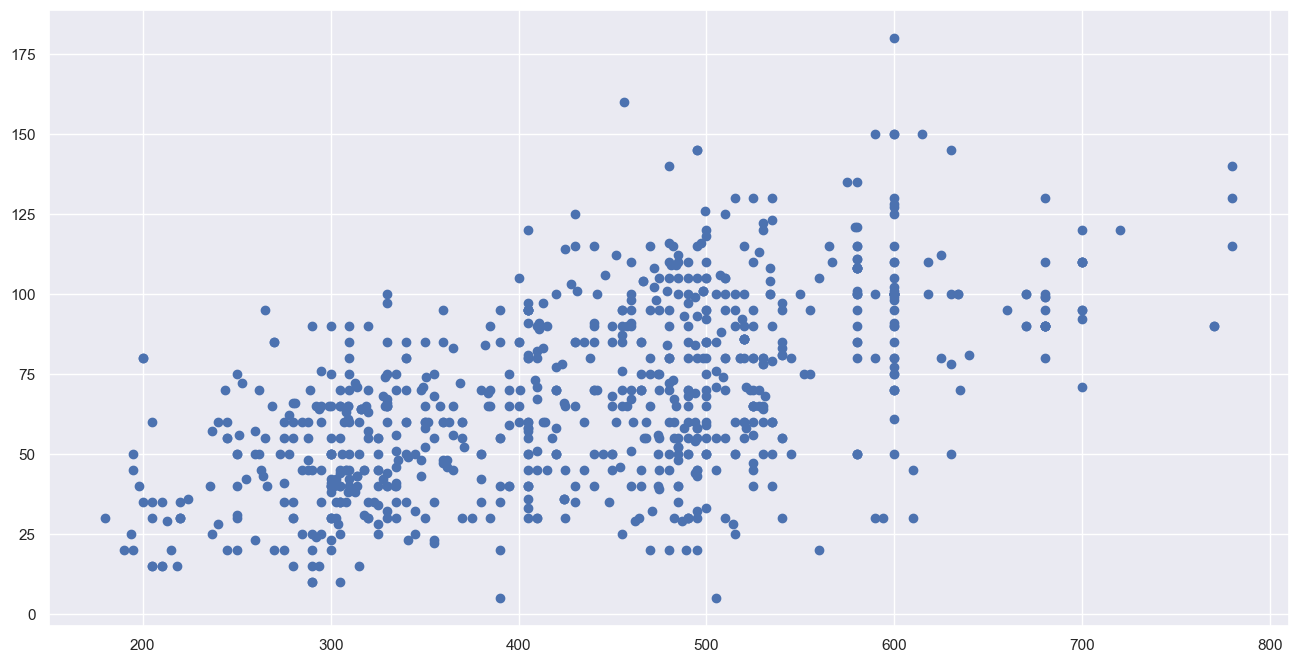

In [5]:
# Extract the Features from the Data
X = pd.DataFrame(pkmndata[["Total", "Speed"]])

# Plot the Raw Data on a 2D grid
f, axes = plt.subplots(1, 1, figsize=(16,8))
plt.scatter(x = "Total", y = "Speed", data = X)

#### **Basic KMeans Clustering**

Guess the number of clusters from the 2D plot, and perform KMeans Clustering.    
We will use the `KMeans` clustering model from `sklearn.cluster` module.

**How K-Means Works**:
1. You choose the number of clusters (or groups) $K$
2. The algorithm randomly places $K$ centroids (center points) on the plot
3. Every data point is assigned to its **nearest** centroid
4. The centroid moves to the mean (average) location of all the points assigned to it
5. Repeat Steps 3 and 4 until the centroids **stop moving** (i.e., convergence)


In [6]:
from sklearn.cluster import KMeans

# Guess the Number of Clusters (we start with an arbitrary guess of 3)
num_clust = 3

# Create Clustering Model using KMeans
# n_init=10 means the algorithm will run 10 times with different random starting centroids, 
# and it will return the best outcome. This helps prevent bad random initializations.
kmeans = KMeans(n_clusters = num_clust, n_init=10)

# Fit the Clustering Model on the Data
kmeans.fit(X)

KMeans(n_clusters=3, n_init=10)

Print the Cluster Centers as Co-ordinates of Features

Now that the model has learned the clusters, we can look at the **cluster centers** or final coordinates of the centroids

In [7]:
# Print the Cluster Centers
print("Features", "\tTotal", "\tSpeed")
print()

for i, center in enumerate(kmeans.cluster_centers_):
    print("Cluster", i, end=":\t")
    for coord in center:
        print(round(coord, 2), end="\t")
    print()

Features 	Total 	Speed

Cluster 0:	305.65	49.36	
Cluster 1:	474.27	73.55	
Cluster 2:	622.57	97.08	


#### **Labeling the Clusters in the Data**

Once fitted, the model can assigned a cluster label (0, 1, or 2) to every singel data point using the `predict` method.

<Axes: xlabel='Cluster', ylabel='count'>

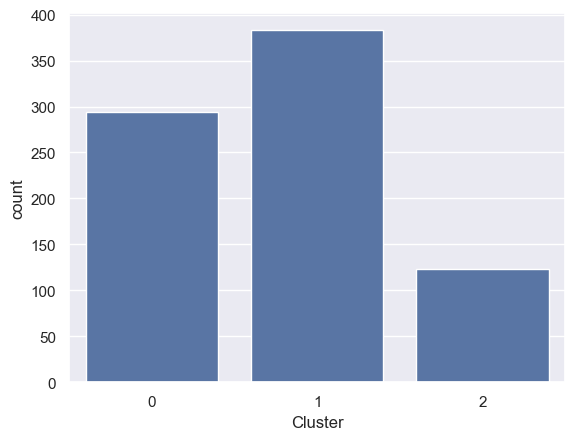

In [8]:
# Predict the Cluster Labels
labels = kmeans.predict(X)

# Append Labels to our original Data so we can track which Pokemon belongs to which cluster
X_labeled = X.copy()
X_labeled["Cluster"] = pd.Categorical(labels)

# Visualizing how many Pokemon fell into each cluster
sb.countplot(x=X_labeled["Cluster"])

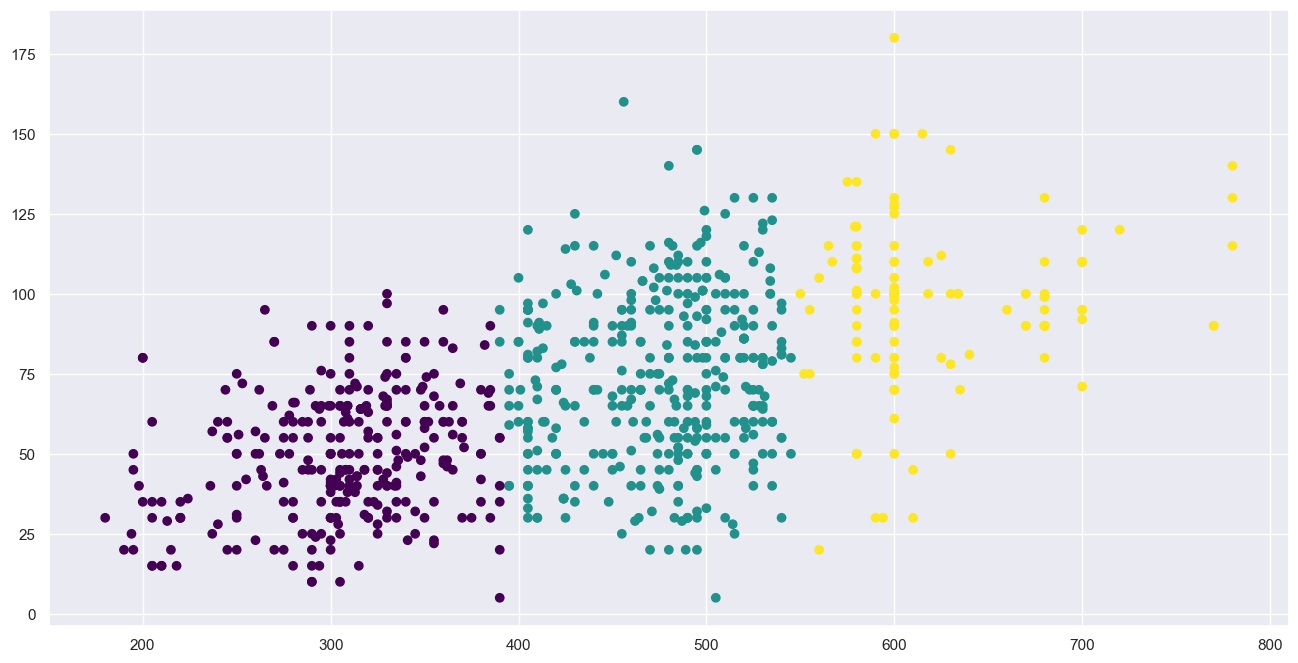

In [9]:
# Visualize the Clusters in the Data
f, axes = plt.subplots(1, 1, figsize=(16,8))
plt.scatter(x = "Total", y = "Speed", c = "Cluster", cmap = 'viridis', data = X_labeled)

---

#### **Finding the Optimal $K$** 

This is called the "elbow method". 

Our original guess of $K=3$ is an *arbitary* one. Therefore, one may ask what is the mathematical *best* number of clusters? 

Firstly, we introduce a metric called **Within-Cluster Sum of Squares** (WCSS), also known as **Inertia**. 

WCSS measures how *tightly* packed the clusters are. It calculates the squared distance between each data point and its assigned centroid.
- If every point is its own cluster, WCSS = 0
- We want a low WCSS, but we don't want $K$ to equal the number of data points.

So now, we run a loop, testing $K$ from 1 to 40, and plot the WCSS. We look for the "Elbow" or the point where adding more clusters yields diminishing returns.

#### Within Cluster Sum of Squares

WithinSS = 0 : Every data point is a cluster on its own    
WithinSS = Variance : Whole dataset is a single cluster

In [10]:
# Print the Within Cluster Sum of Squares
print("Within Cluster Sum of Squares :", kmeans.inertia_)

Within Cluster Sum of Squares : 2118651.4360573245


Vary the Number of Clusters to obtain a distribution of WithinSS.

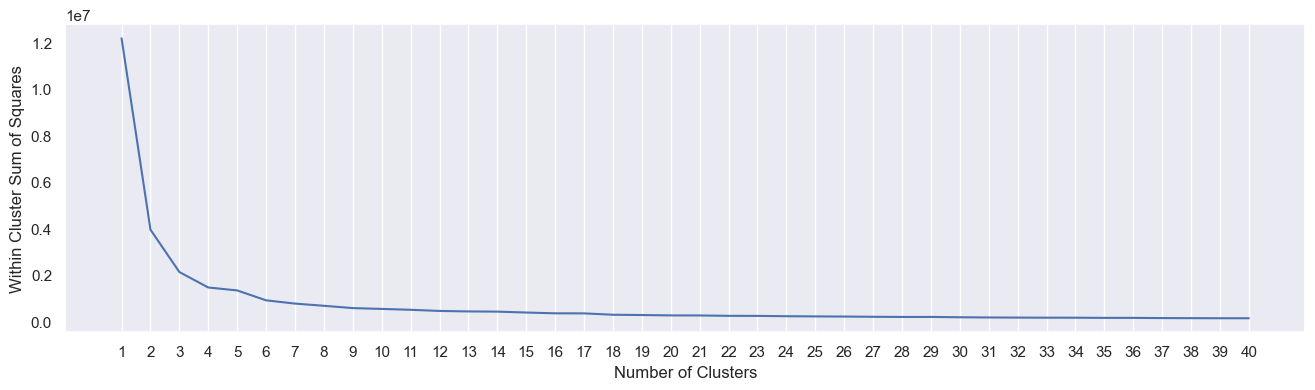

In [11]:
# Import KMeans from sklearn.cluster
import warnings
warnings.filterwarnings("ignore",category=UserWarning,module="sklearn")
from sklearn.cluster import KMeans

# Extract the Features from the Data
X = pd.DataFrame(pkmndata[["Total", "Speed"]])

# Vary the Number of Clusters
min_clust = 1
max_clust = 40

# Compute Within Cluster Sum of Squares (Inertia) for each K
within_ss = []
for num_clust in range(min_clust, max_clust+1):
    kmeans = KMeans(n_clusters = num_clust)
    kmeans.fit(X)
    within_ss.append(kmeans.inertia_)   # .inertia_ is scikit-learn's attribute for WCSS

# Plot Within SS vs Number of Clusters
f, axes = plt.subplots(1, 1, figsize=(16,4))
plt.plot(range(min_clust, max_clust+1), within_ss)
plt.xlabel('Number of Clusters')
plt.ylabel('Within Cluster Sum of Squares')
plt.xticks(np.arange(min_clust, max_clust+1, 1.0))
plt.grid(which='major', axis='y')
plt.show()

So best on the plot above, the steep drop starts to level off around $K=4$. So, this is our "elbow".

#### Optimal Clustering

Choose the "optimal" number of clusters from the plot.

Cluster 0:	625.46	98.1	
Cluster 1:	396.6	64.12	
Cluster 2:	496.52	75.24	
Cluster 3:	289.79	47.46	

Within Cluster Sum of Squares : 1454411.0967934756



<Axes: xlabel='Cluster', ylabel='count'>

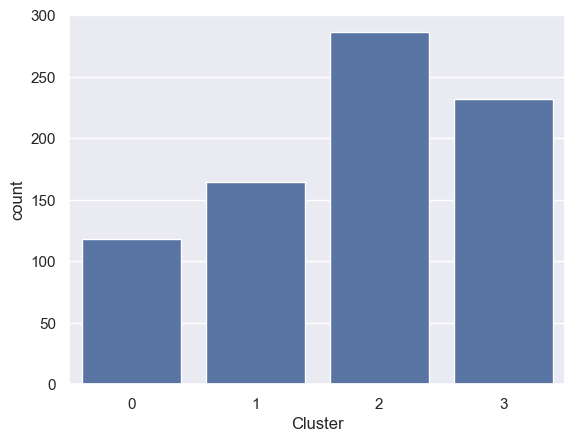

In [12]:
# Set "optimal" Number of Clusters
num_clust = 4

# Create Clustering Model using KMeans
kmeans = KMeans(n_clusters = num_clust, n_init=10)                 

# Fit the Clustering Model on the Data
kmeans.fit(X)

# Print the Cluster Centers
for i, center in enumerate(kmeans.cluster_centers_):
    print("Cluster", i, end=":\t")
    for coord in center:
        print(round(coord, 2), end="\t")
    print()
print()

# Print the Within Cluster Sum of Squares
print("Within Cluster Sum of Squares :", kmeans.inertia_)
print()

# Predict the Cluster Labels
labels = kmeans.predict(X)

# Append Labels to the Data
X_labeled = X.copy()
X_labeled["Cluster"] = pd.Categorical(labels)

# Summary of the Cluster Labels
sb.countplot(x=X_labeled["Cluster"])

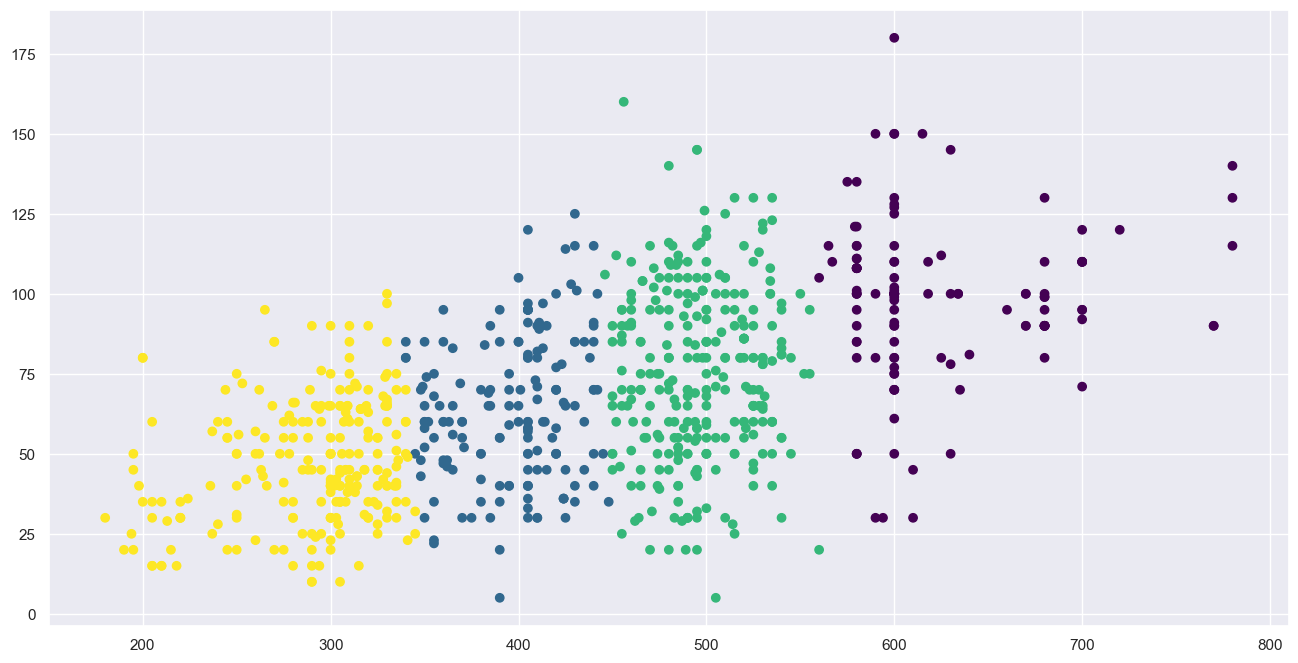

In [13]:
# Visualize the Clusters in the Data
f, axes = plt.subplots(1, 1, figsize=(16,8))
plt.scatter(x = "Total", y = "Speed", c = "Cluster", cmap = 'viridis', data = X_labeled)

To really understand what these clusters represent in the context of our data, we can use boxplots and barcharts to profile them.

For example, one cluster might represent "Slow, weak Pokemon", while another represents "Fast, strong Pokemon".

#### Interpret the Clusters

Try to interpret the clusters by exploring the Features across them.

<Axes: xlabel='Speed', ylabel='Cluster'>

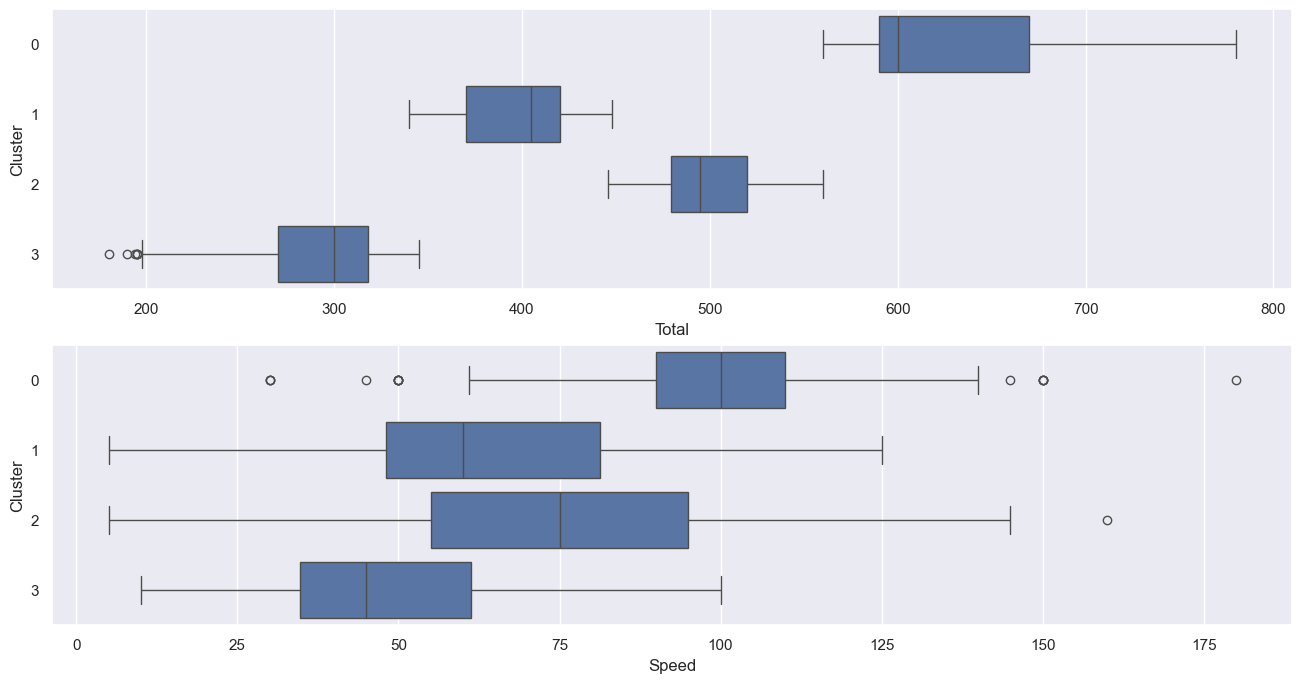

In [14]:
# Boxplots for the Features against the Clusters
f, axes = plt.subplots(2, 1, figsize=(16,8))
sb.boxplot(x = 'Total', y = 'Cluster', data = X_labeled, ax = axes[0])
sb.boxplot(x = 'Speed', y = 'Cluster', data = X_labeled, ax = axes[1])

/var/folders/3_/5046_kpd33s64hy18xzlly300000gn/T/ipykernel_2044/3914299649.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_data = pd.DataFrame(X_labeled.groupby(by = "Cluster").mean())


<Axes: xlabel='Cluster'>

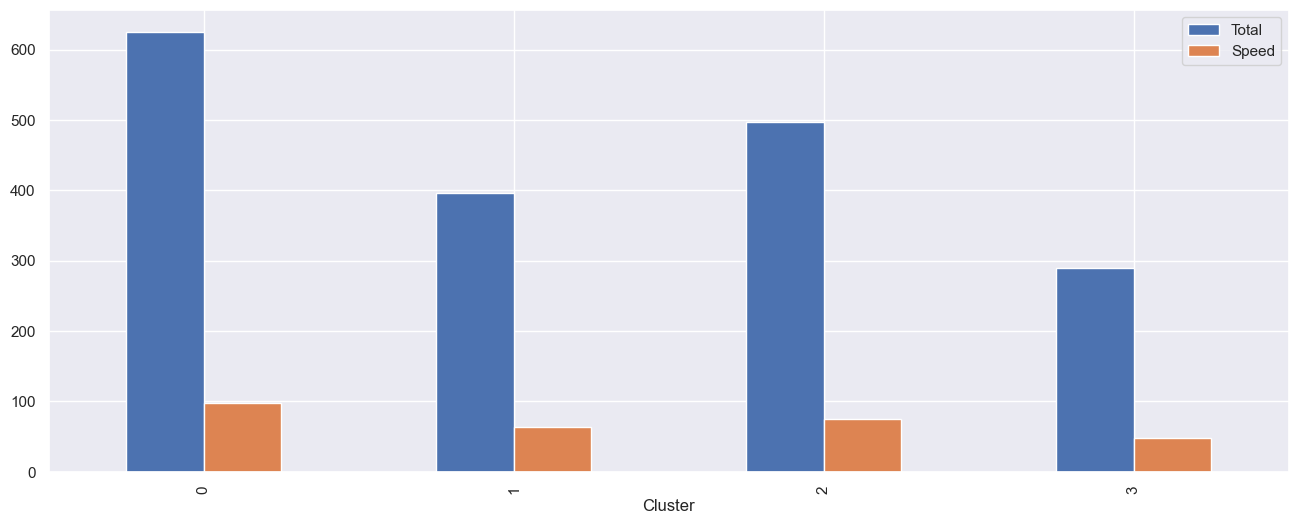

In [15]:
# Average Behaviour of each Cluster
cluster_data = pd.DataFrame(X_labeled.groupby(by = "Cluster").mean())
cluster_data.plot.bar(figsize = (16,6))

---

## KMeans++ Clustering (Bi-Variate)

Standard K-Means relies on random initialization for its first centroids. Sometimes, random luck places two centroids very close to each other, which can result in poor convergence.

Therefore, we use **KMeans++**, which is an *optimization*. It places the first centroid randomly, but then places subsequent centroids *as far away* from the existing ones as possible.

This, *generally*, improves the speed and accuracy of the algorithm.




Set up a Bi-Variate Clustering problem on the Pokemon Dataset.   
Features to be used for Clustering : **Total, Speed**       

In this case, we will use the optimized `KMeans++` algorithm.

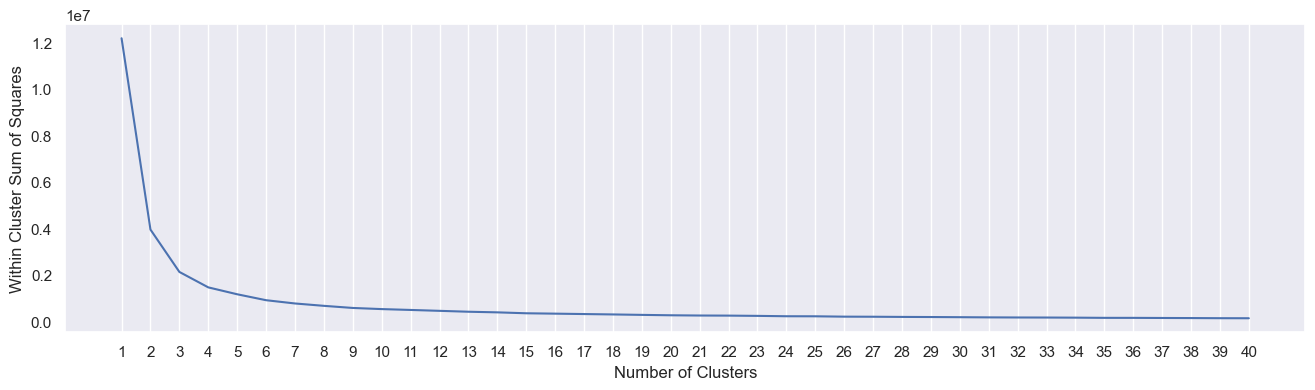

In [16]:
# Import KMeans from sklearn.cluster
from sklearn.cluster import KMeans

# Extract the Features from the Data
X = pd.DataFrame(pkmndata[["Total", "Speed"]])

# Set the Initialization to KMeans++
init_algo = 'k-means++'

# Vary the Number of Clusters
min_clust = 1
max_clust = 40

# Compute Within Cluster Sum of Squares
within_ss = []
for num_clust in range(min_clust, max_clust+1):
    kmeans = KMeans(n_clusters = num_clust,        # number of clusters
                    init = init_algo,              # initialization algorithm
                    n_init = 5)                    # number of initializations
    kmeans.fit(X)
    within_ss.append(kmeans.inertia_)

# Plot Within SS vs Number of Clusters
f, axes = plt.subplots(1, 1, figsize=(16,4))
plt.plot(range(min_clust, max_clust+1), within_ss)
plt.xlabel('Number of Clusters')
plt.ylabel('Within Cluster Sum of Squares')
plt.xticks(np.arange(min_clust, max_clust+1, 1.0))
plt.grid(which='major', axis='y')
plt.show()

#### Optimal Clustering

Choose the "optimal" number of clusters from the plot.

Features 	Total 	Speed

Cluster 0:	396.6	64.12	
Cluster 1:	496.52	75.24	
Cluster 2:	625.46	98.1	
Cluster 3:	289.79	47.46	

Within Cluster Sum of Squares : 1454411.0967934756



<Axes: xlabel='Cluster', ylabel='count'>

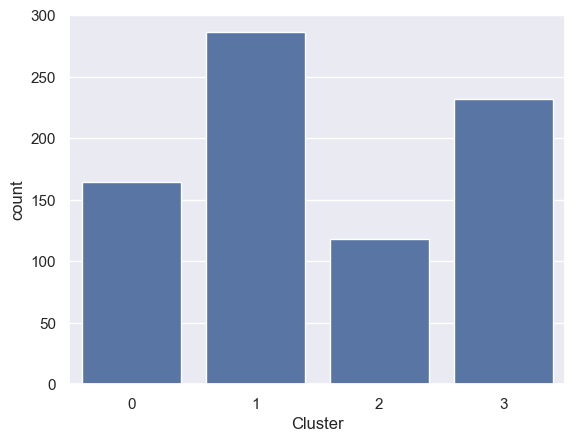

In [17]:
# Set "optimal" Number of Clusters
num_clust = 4

# Set the Initialization to KMeans++
init_algo = 'k-means++'

# Create Clustering Model using KMeans
kmeans = KMeans(n_clusters = num_clust, init = init_algo, n_init = 20)                 

# Fit the Clustering Model on the Data
kmeans.fit(X)

# Print the Cluster Centers
print("Features", "\tTotal", "\tSpeed")
print()

for i, center in enumerate(kmeans.cluster_centers_):
    print("Cluster", i, end=":\t")
    for coord in center:
        print(round(coord, 2), end="\t")
    print()
print()

# Print the Within Cluster Sum of Squares
print("Within Cluster Sum of Squares :", kmeans.inertia_)
print()

# Predict the Cluster Labels
labels = kmeans.predict(X)

# Append Labels to the Data
X_labeled = X.copy()
X_labeled["Cluster"] = pd.Categorical(labels)

# Summary of the Cluster Labels
sb.countplot(x=X_labeled["Cluster"])

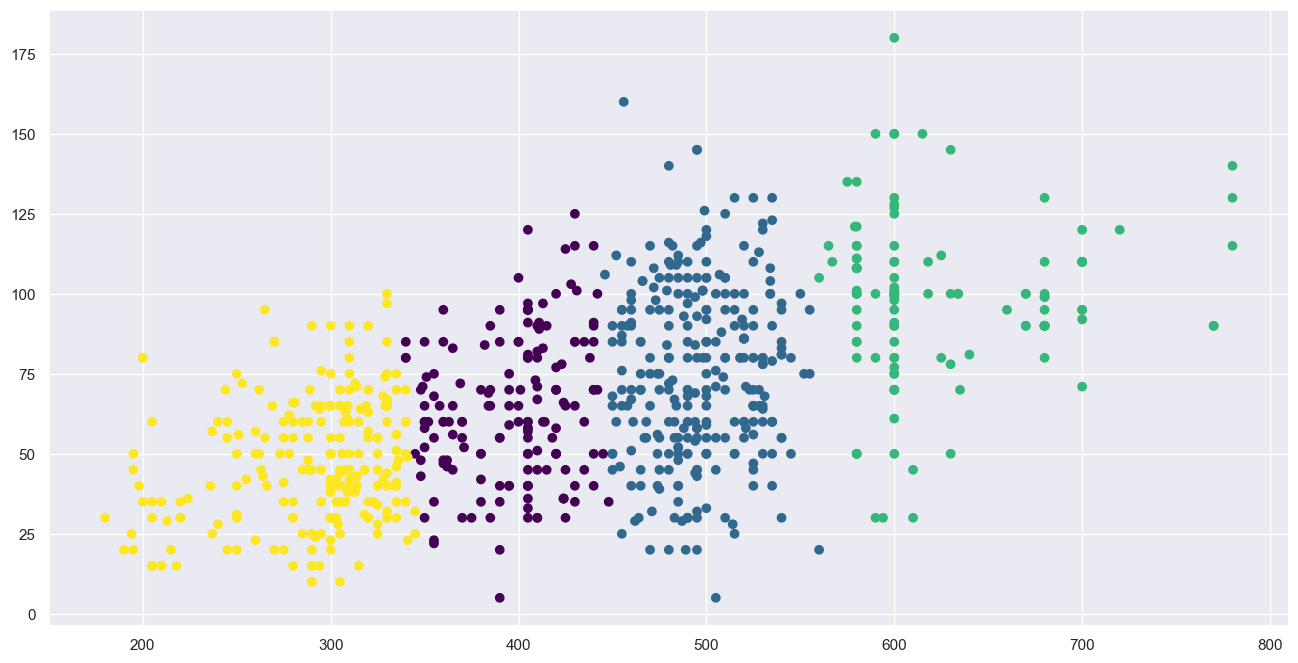

In [18]:
# Visualize the Clusters in the Data
f, axes = plt.subplots(1, 1, figsize=(16,8))
plt.scatter(x = "Total", y = "Speed", c = "Cluster", cmap = 'viridis', data = X_labeled)

#### Interpret the Clusters

Try to interpret the clusters by exploring the Features across them.

<Axes: xlabel='Speed', ylabel='Cluster'>

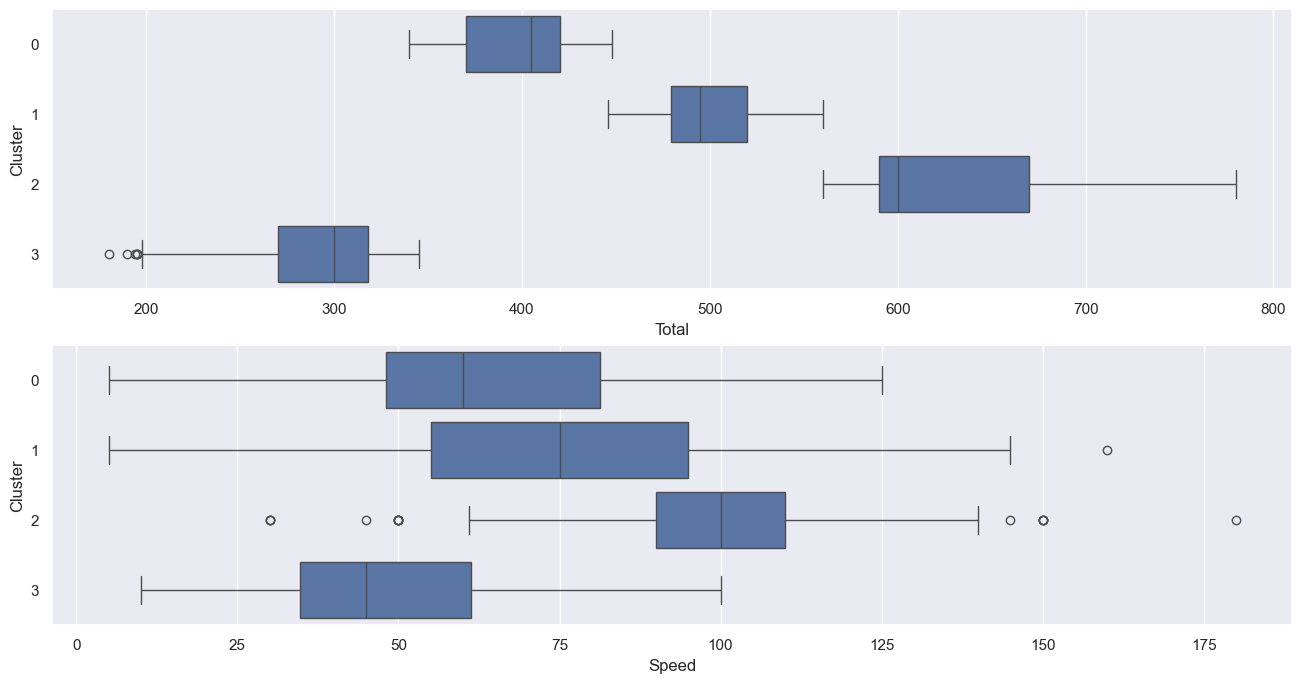

In [19]:
# Boxplots for the Features against the Clusters
f, axes = plt.subplots(2, 1, figsize=(16,8))
sb.boxplot(x = 'Total', y = 'Cluster', data = X_labeled, ax = axes[0])
sb.boxplot(x = 'Speed', y = 'Cluster', data = X_labeled, ax = axes[1])

---

## Multi-Variate Clustering

Set up a Multi-Variate Clustering problem on the Pokemon Dataset.   
Features : **Total, HP, Attack, Defense, Sp. Atk, Sp. Def, Speed**  

In this case, we will use the optimized `KMeans++` algorithm.

We can pass *all* the features into K-Means simulatenously. The math can scale into an $N$-dimensional space (Bi-Variate would be 2-D space). 

The only challenge is *visualizing* it, because humans cannot see a 6-D scatter plot.

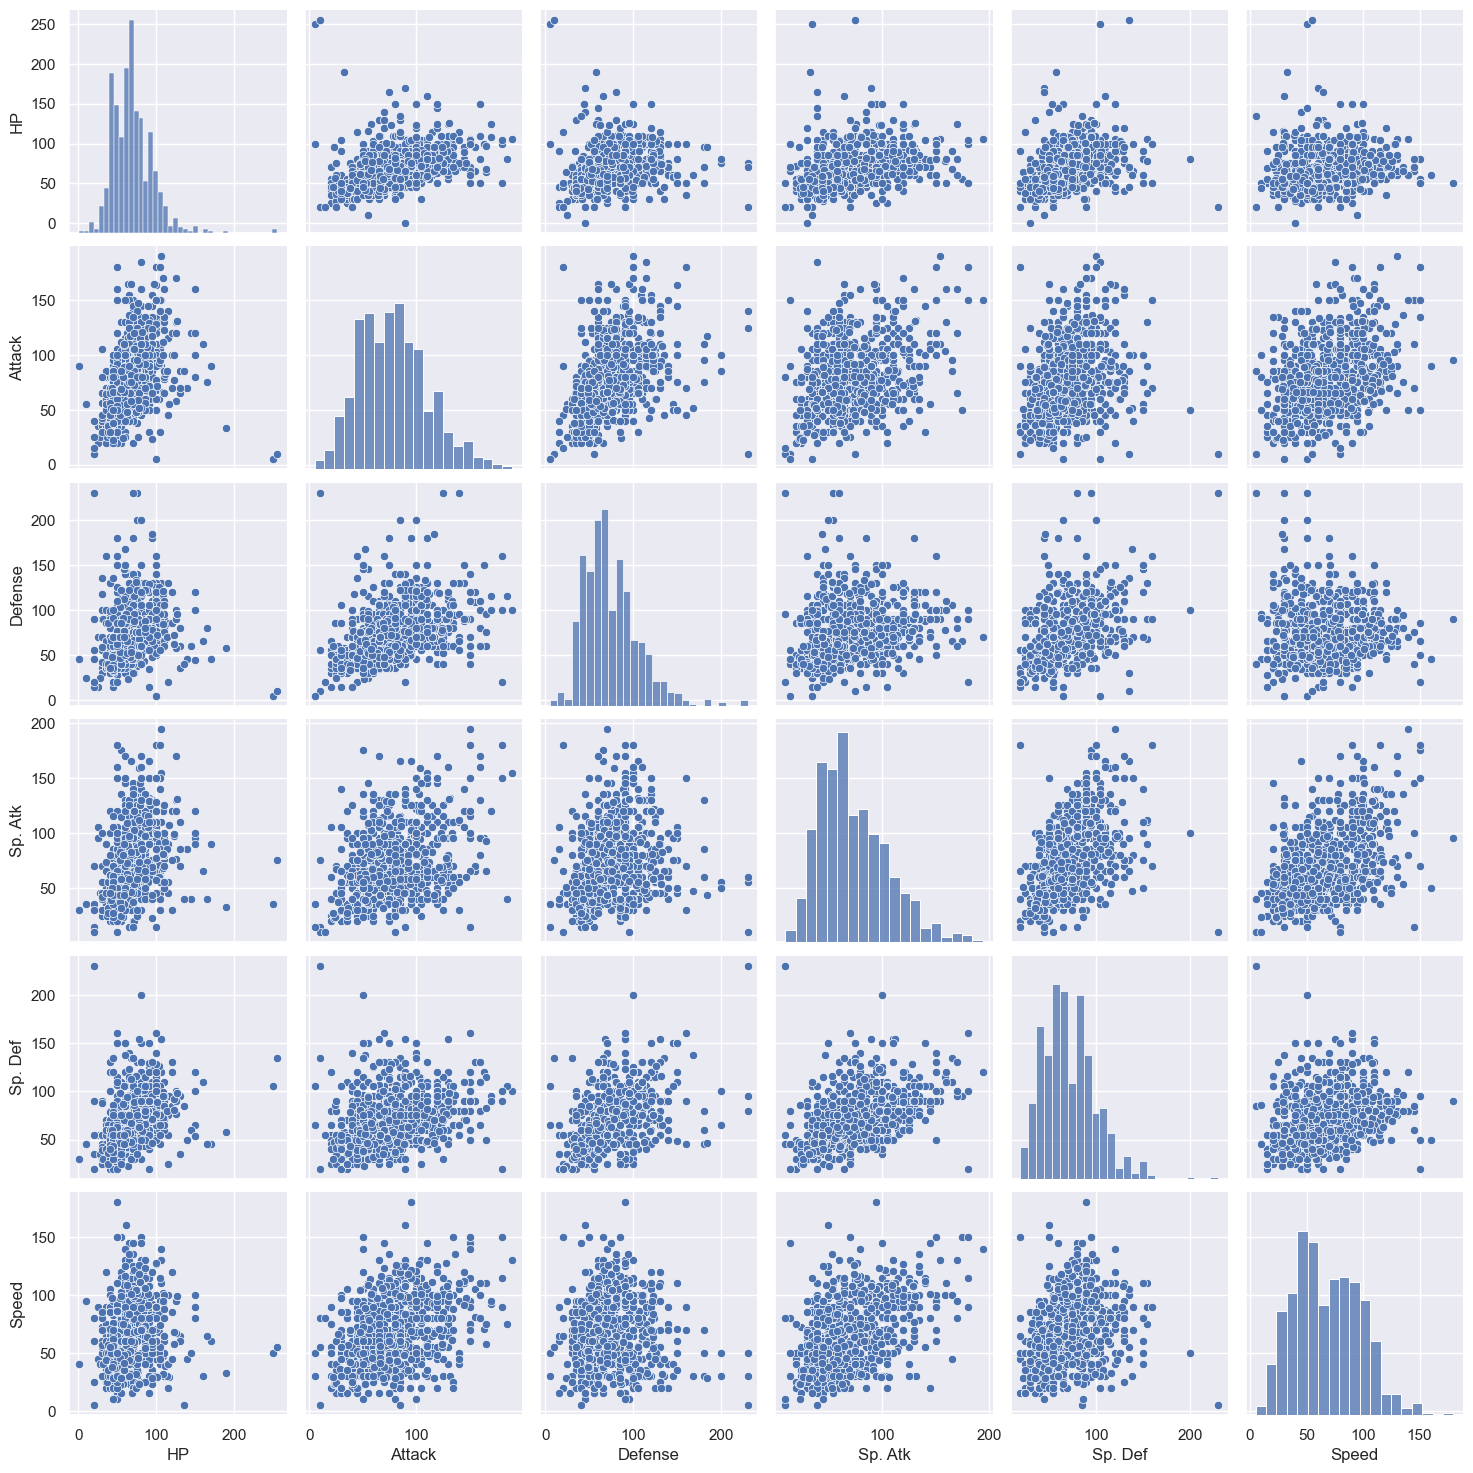

In [20]:
# Extract the Features from the Data
X = pd.DataFrame(pkmndata[["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]]) 

# Plot the Raw Data on 2D grids
sb.pairplot(X)

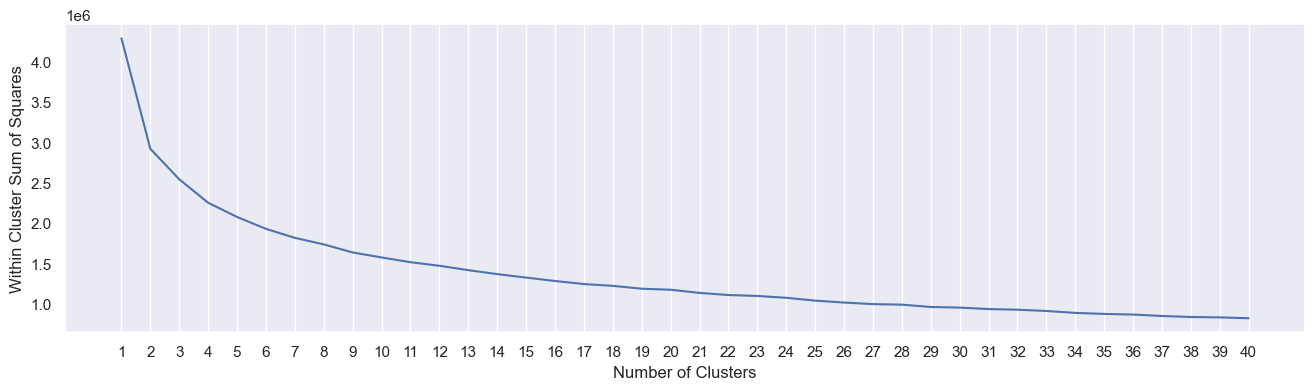

In [21]:
# Vary the Number of Clusters
min_clust = 1
max_clust = 40
init_algo = 'k-means++'

# Compute Within Cluster Sum of Squares
within_ss = []
for num_clust in range(min_clust, max_clust+1):
    kmeans = KMeans(n_clusters = num_clust, init = init_algo, n_init = 5)
    kmeans.fit(X)
    within_ss.append(kmeans.inertia_)

# Angle Plot : Within SS vs Number of Clusters
f, axes = plt.subplots(1, 1, figsize=(16,4))
plt.plot(range(min_clust, max_clust+1), within_ss)
plt.xlabel('Number of Clusters')
plt.ylabel('Within Cluster Sum of Squares')
plt.xticks(np.arange(min_clust, max_clust+1, 1.0))
plt.grid(which='major', axis='y')
plt.show()

In [22]:
# Import essential models from sklearn
from sklearn.cluster import KMeans

# Set "optimal" Clustering Parameters
num_clust = 6
init_algo = 'k-means++'

# Create Clustering Model using KMeans
kmeans = KMeans(n_clusters = num_clust,         
               init = init_algo,
               n_init = 20)                 

# Fit the Clustering Model on the Data
kmeans.fit(X)

KMeans(n_clusters=6, n_init=20)

Features 	HP 	Att 	Def 	SpAtk 	SpDef 	Speed

Cluster 0:	67.34	75.51	66.52	91.6	76.78	99.1	
Cluster 1:	50.07	54.06	51.69	47.83	48.99	50.04	
Cluster 2:	78.75	110.15	87.37	58.55	71.49	71.66	
Cluster 3:	91.13	125.24	94.38	122.53	98.37	97.58	
Cluster 4:	92.91	70.63	78.5	87.28	89.98	55.23	
Cluster 5:	61.95	81.78	149.24	63.29	100.66	42.0	

Within Cluster Sum of Squares : 1926388.0108917474



<Axes: xlabel='Cluster', ylabel='count'>

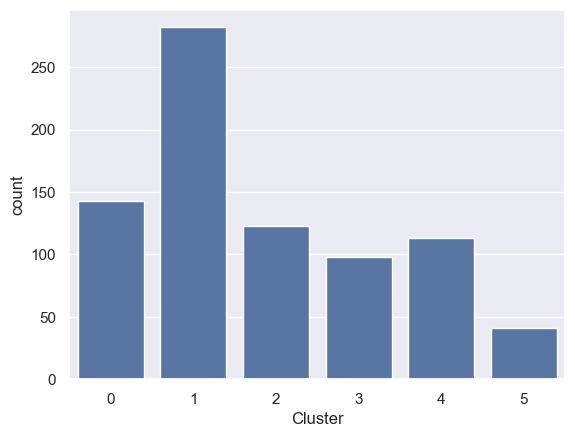

In [23]:
# Print the Cluster Centers
print("Features", "\tHP", "\tAtt", "\tDef", "\tSpAtk", "\tSpDef", "\tSpeed")
print()

for i, center in enumerate(kmeans.cluster_centers_):
    print("Cluster", i, end=":\t")
    for coord in center:
        print(round(coord, 2), end="\t")
    print()
print()

# Print the Within Cluster Sum of Squares
print("Within Cluster Sum of Squares :", kmeans.inertia_)
print()

# Predict the Cluster Labels
labels = kmeans.predict(X)

# Append Labels to the Data
X_labeled = X.copy()
X_labeled["Cluster"] = pd.Categorical(labels)

# Summary of the Cluster Labels
sb.countplot(x=X_labeled["Cluster"])

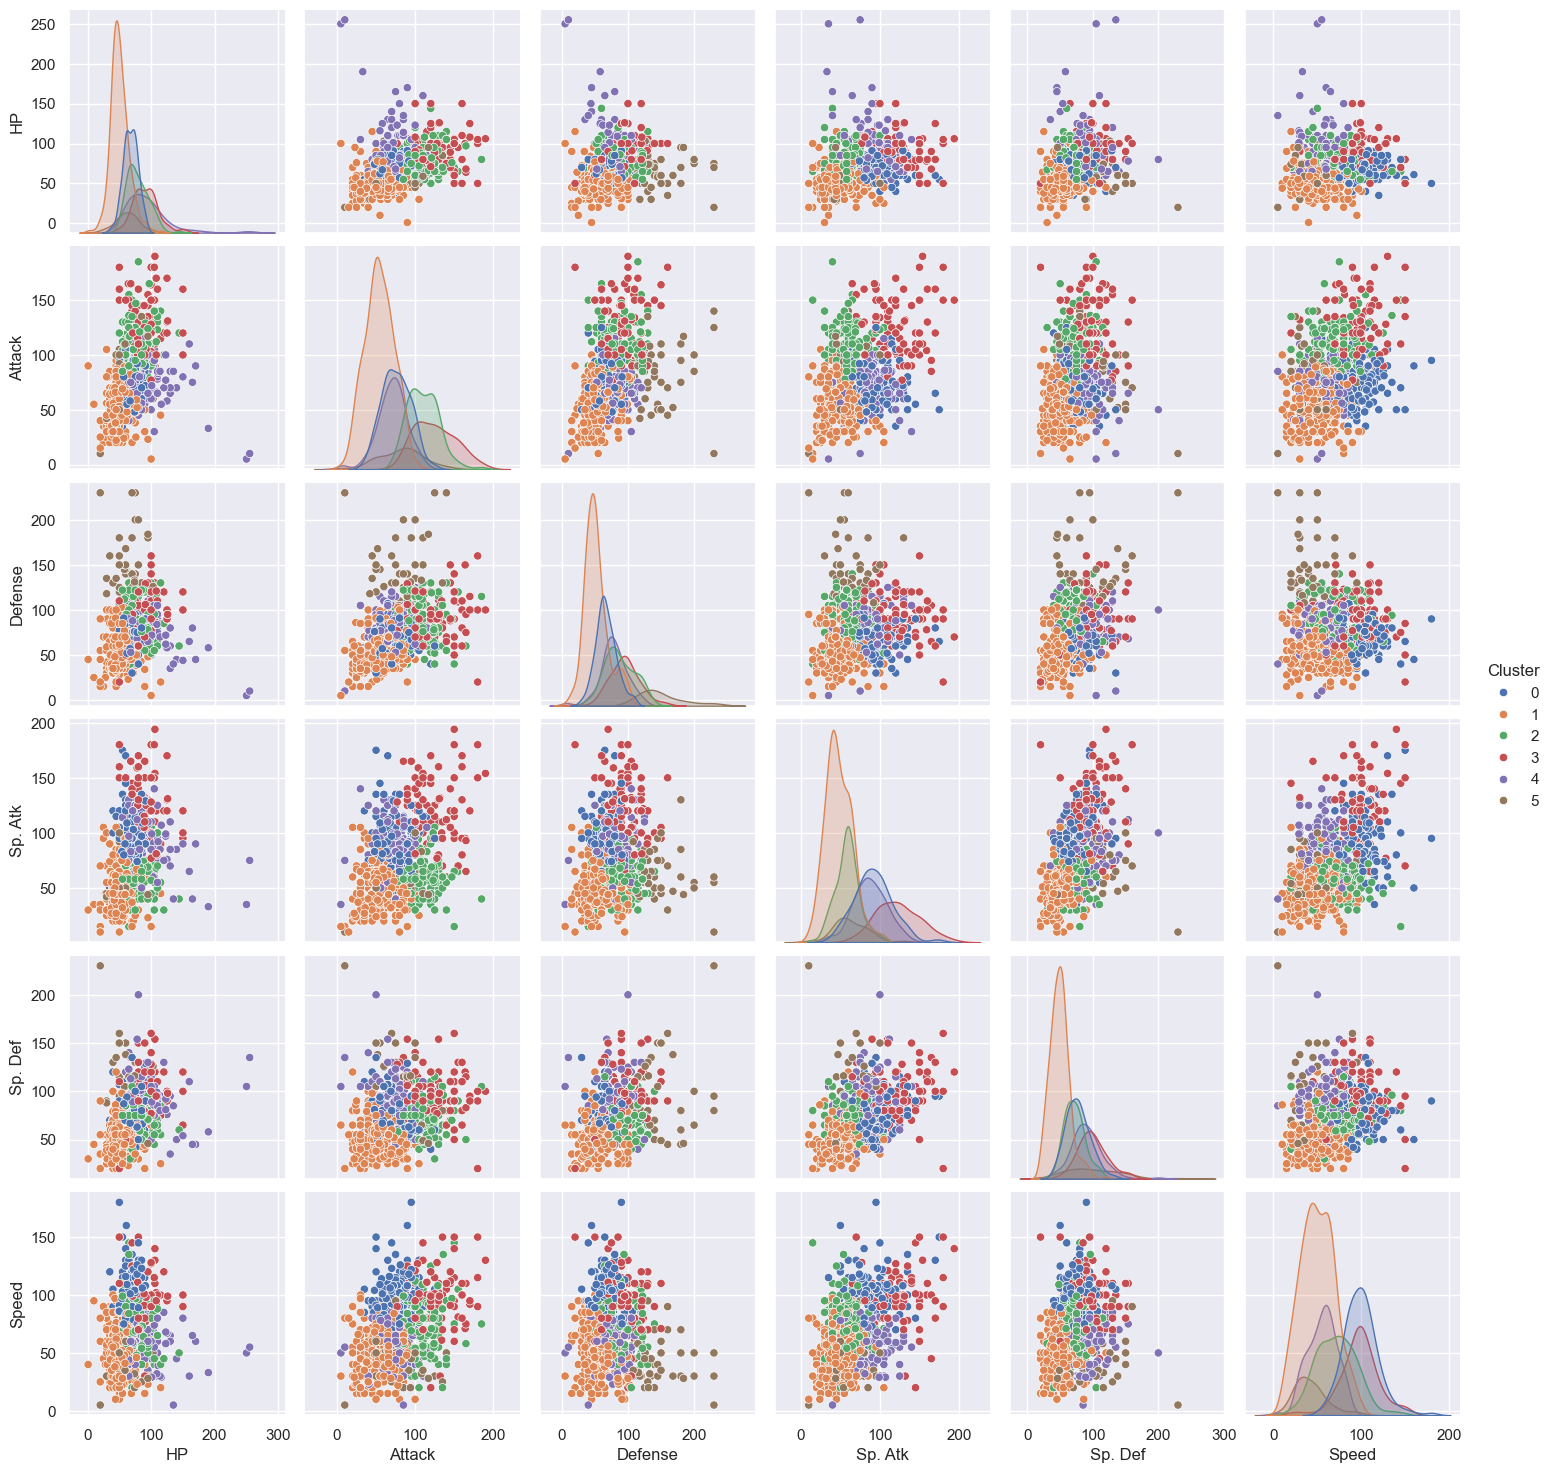

In [24]:
# Plot the Clusters on 2D grids
sb.pairplot(X_labeled, vars = X.columns.values, hue = "Cluster")

<Axes: xlabel='Speed', ylabel='Cluster'>

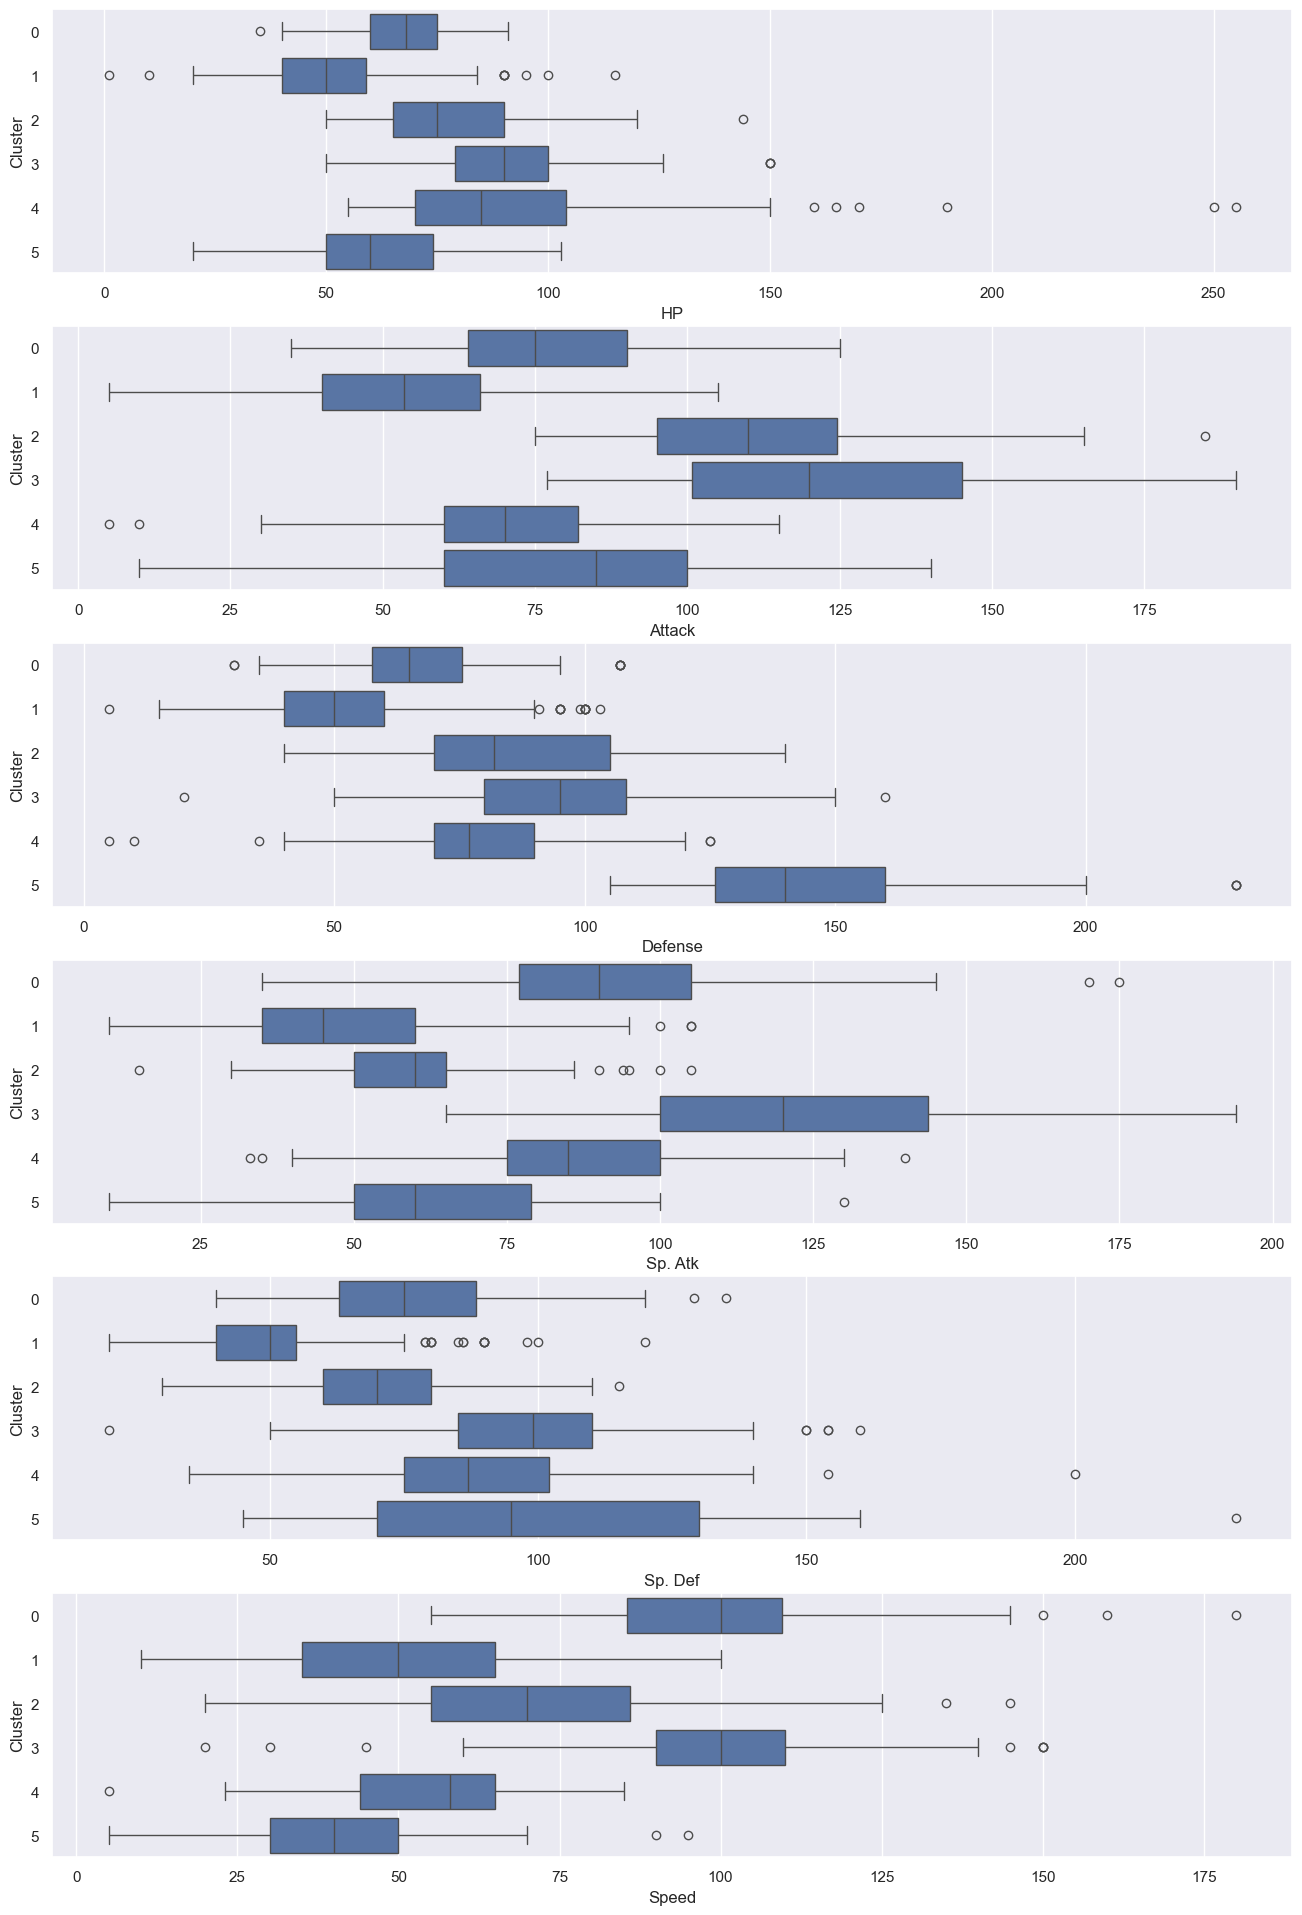

In [25]:
# Boxplots for all Features against the Clusters
f, axes = plt.subplots(6, 1, figsize=(16,24))
sb.boxplot(x = 'HP', y = 'Cluster', data = X_labeled, ax = axes[0])
sb.boxplot(x = 'Attack', y = 'Cluster', data = X_labeled, ax = axes[1])
sb.boxplot(x = 'Defense', y = 'Cluster', data = X_labeled, ax = axes[2])
sb.boxplot(x = 'Sp. Atk', y = 'Cluster', data = X_labeled, ax = axes[3])
sb.boxplot(x = 'Sp. Def', y = 'Cluster', data = X_labeled, ax = axes[4])
sb.boxplot(x = 'Speed', y = 'Cluster', data = X_labeled, ax = axes[5])

/var/folders/3_/5046_kpd33s64hy18xzlly300000gn/T/ipykernel_2044/3914299649.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_data = pd.DataFrame(X_labeled.groupby(by = "Cluster").mean())


<Axes: xlabel='Cluster'>

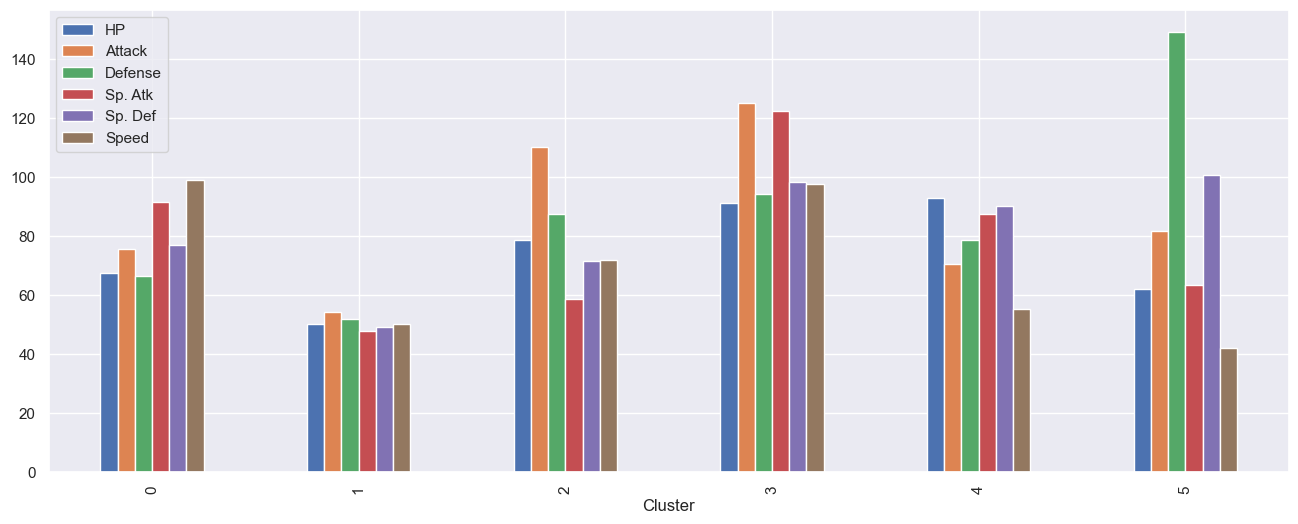

In [26]:
# Average Behaviour of each Cluster
cluster_data = pd.DataFrame(X_labeled.groupby(by = "Cluster").mean())
cluster_data.plot.bar(figsize = (16,6))

### **Summary**

Clustering is a form of **unsupervised machine learning**. 

Unlike supervised learning, where we teach the model to predict a *specific answer* (e.g., what type of pokemon it is), unsupervised learning algorithms are given data without any pre-labeled answers. 

The goal here is to find **hidden structures, natural groupings, or patterns** within the raw data.

#### **The K-Means Algorithm**

K-Means groups data into a pre-defined number of clusters ($K$). The algorithm groups data based on "distance" or similarity, and operates in a loop: 
1. **Initialization**: The algorithm randomly places $K$ points, called **centroids**, into the data space 

2. **Assignment**: Each data point calculates its distance to all $K$ centroids, and assigns itself to the closest one. 

3. **Update**: Once all points are assigned, the algorithm calculates the exact center (mean) of each newly formed cluster. The centroid is then moved to this new mean coordinate.

4. **Convergence**: You repeat steps 2 and 3 until the centroids stop moving. At this point, we say the algorithm has "converged", and the clusters are finalized.

#### **K-Means++ Optimization**

Standard K-Means places the initial centroids completely at random. If two centroids accidentally start close to each other, the algorithm might converge to a **suboptimal grouping**. 

**K-Means++** solves this by placing initial centroids as far away from each other as possible, which speeds up convergence and *generally* yields more accurate clusters. 

#### **What is the optimal K**

We answer this question using the **Within-Cluster Sum of Squares** (WCSS), or also known as **Inertia**. 

WCSS measures the total mathematical variance within our clusters. It calculates the squared distance between each data point and its assigned centroid. 

For math nerds, the formula is:

$$\mathrm{WCSS} = \sum^K_{i=1} \sum_{x \in C_i} (x - \mu_i)^2$$

Where $K$ is your **number of clusters**, $C_i$ is the $i$-th cluster, $x$ is a **data point**, and $\mu_i$ is the **centroid of that cluster**.

For non-math nerds, just note that:
- A **high WCSS** means the clusters are wide and loose
- A **low WCSS** means the clusters are tight and dense

If we plot WCSS across a range of $K$ values, the WCSS will always drop as $K$ increases. 
- **However**, the rate of that drop will slow, creating an *'elbow'* shape in the graph
- The optimal number of clusters is usually found at the hinge of that elbow
- In layman terms, it is the point where adding more clusters no longer *significantly tightens* the groupings

#### **Remember to Interpretate**

Your algorithm can group data into $K$ clusters, but it cannot tell you **what** those clusters **mean**. 

Your job is to profile these clusters. Use tools like *boxplots, pairplots*, and *barcharts* to compare these features across the clusters. 

We can then assign them *human-readable* labels. For example, "Fast Glass Cannon" pokemon vs "Slow Tanky" pokemon.

### **Cookbook**

Again, I provided a simple *barebones* script for your reference. If anything goes wrong, don't scold me

Testing K values from 1 to 10 to find the 'Elbow'...


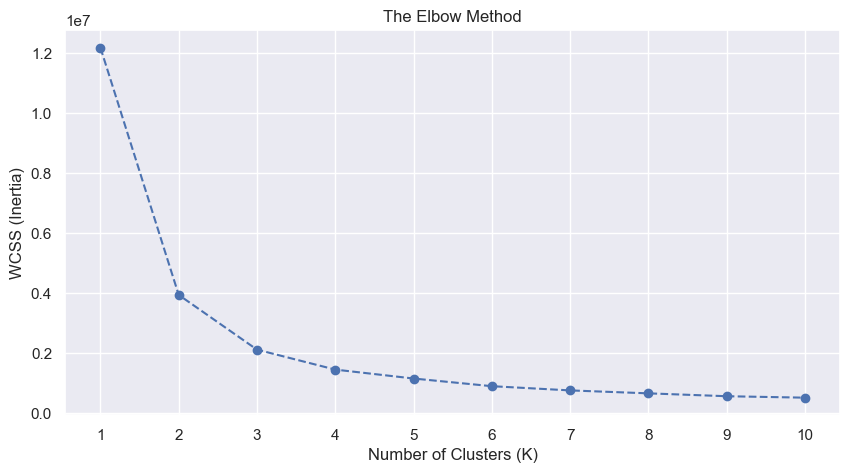

Training final model with K=3...

Cluster Populations:
Cluster
0    294
1    123
2    383
Name: count, dtype: int64


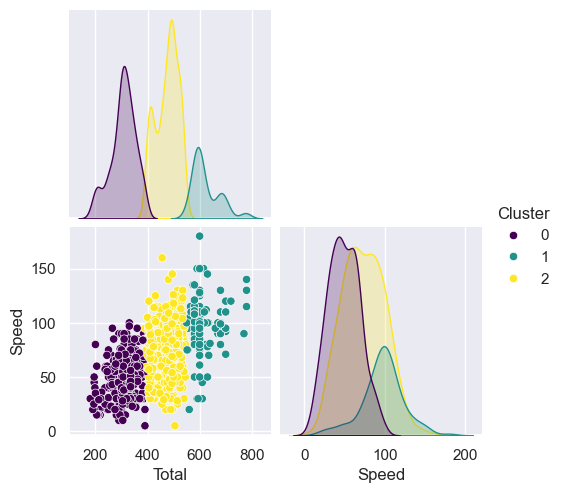


Average Feature Values per Cluster:
              Total      Speed
Cluster                       
0        305.653061  49.360544
1        622.569106  97.081301
2        474.266319  73.548303


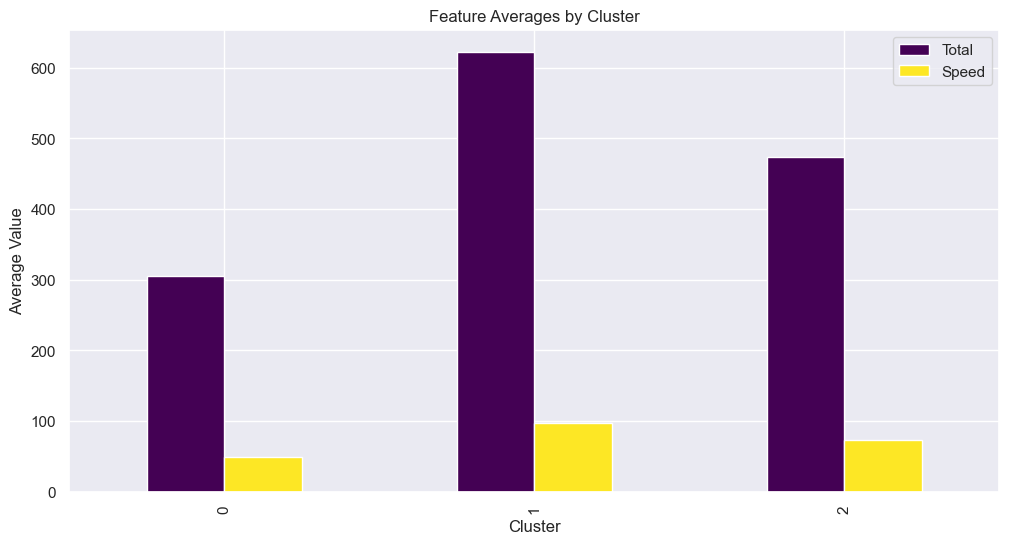

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.cluster import KMeans
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
sb.set() # Set seaborn style for prettier graphs

# ====== EDIT THIS SECTION =====
CSV_FILEPATH = 'pokemonData.csv'
FEATURE_COLS = ['Total', 'Speed']
# ====== REMEMBER TO EDIT ======

# Load your dataset
df = pd.read_csv(CSV_FILEPATH)

# Note: K-Means relies on distance, so you can ONLY use numerical columns
X = df[FEATURE_COLS].copy() # We make a copy to avoid altering the original raw data

# The Elbow Method (Finding your K)
min_k = 1
max_k = 10
print(f"Testing K values from {min_k} to {max_k} to find the 'Elbow'...")

wcss = []
for k in range(min_k, max_k + 1):
    # We use k-means++ for smarter initialization
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    model.fit(X)
    wcss.append(model.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(range(min_k, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(min_k, max_k + 1))
plt.grid(True)
plt.show()

# Train the Final Model
# Look at the graph generated above. Find the "elbow" point, and type that number below.
optimal_k = 3 # <--- CHANGE THIS NUMBER BASED ON YOUR GRAPH

print(f"Training final model with K={optimal_k}...")
final_model = KMeans(n_clusters=optimal_k, init='k-means++', n_init=20, random_state=42)
final_model.fit(X)

# Predict which cluster every row belongs to
cluster_labels = final_model.predict(X)

# Attach the new labels back to your data so you can see who went where
X_labeled = X.copy()
X_labeled["Cluster"] = cluster_labels

# Visualize and Interpret
print("\nCluster Populations:")
print(X_labeled["Cluster"].value_counts().sort_index())

# Plot a Pairplot to see how the clusters separate across all your features
sb.pairplot(X_labeled, vars=FEATURE_COLS, hue="Cluster", palette="viridis", corner=True)
plt.show()

# Look at the average values for each cluster to figure out what they mean
cluster_averages = X_labeled.groupby("Cluster").mean()
print("\nAverage Feature Values per Cluster:")
print(cluster_averages)

# Plot a bar chart of the averages for easy comparison
cluster_averages.plot.bar(figsize=(12, 6), colormap='viridis')
plt.title('Feature Averages by Cluster')
plt.ylabel('Average Value')
plt.show()